# **LAB SLOT 09: Mining Sequential Patterns**

**Sinh viên:** Nguyễn Văn Anh Duy  
**MSSV:** SE181823  
**Lớp:** AI1803


## 1. Import Libraries & Load Dataset


In [13]:
# Import các thư viện cần thiết
import pandas as pd
import numpy as np
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

# Thiết lập style cho visualization
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Đã import thư viện thành công!")


Đã import thư viện thành công!


In [14]:
# Tải dữ liệu giao dịch khách hàng
# Đọc file dưới dạng text để xử lý chuỗi phân cách bởi dấu phẩy
with open('customer_transactions_dataset.csv', 'r') as f:
    lines = f.readlines()

# Phân tích dữ liệu thủ công
data = []
for line in lines[1:]:  # Bỏ qua header
    parts = line.strip().split(',', 1)  # Chỉ tách tại dấu phẩy đầu tiên
    if len(parts) == 2:
        trans_id = parts[0]
        sequence = parts[1]
        data.append({'TransactionID': int(trans_id), 'Sequence': sequence})

df = pd.DataFrame(data)

print("Kích thước dataset:", df.shape)
print("\n10 dòng đầu tiên:")
print(df)
print("\nThông tin dataset:")
print(df.info())


Kích thước dataset: (10, 2)

10 dòng đầu tiên:
   TransactionID                      Sequence
0              1  Apple, Banana, Cereal, Donut
1              2          Apple, Cereal, Donut
2              3                 Banana, Donut
3              4                  Apple, Donut
4              5         Apple, Banana, Cereal
5              6                 Cereal, Donut
6              7          Apple, Banana, Donut
7              8                 Apple, Banana
8              9                Banana, Cereal
9             10          Apple, Cereal, Donut

Thông tin dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   TransactionID  10 non-null     int64 
 1   Sequence       10 non-null     object
dtypes: int64(1), object(1)
memory usage: 288.0+ bytes
None


In [15]:
# Tiền xử lý dữ liệu - chuyển đổi chuỗi thành danh sách
def preprocess_sequences(df):
    sequences = []
    for idx, row in df.iterrows():
        # Tách bằng dấu phẩy và loại bỏ khoảng trắng
        items = [item.strip() for item in row['Sequence'].split(',')]
        sequences.append(items)
    return sequences

# Chuyển đổi sang định dạng chuỗi
sequences = preprocess_sequences(df)

print("Số lượng chuỗi:", len(sequences))
print("\nMẫu chuỗi:")
for i, seq in enumerate(sequences[:5], 1):
    print(f"Giao dịch {i}: {seq}")


Số lượng chuỗi: 10

Mẫu chuỗi:
Giao dịch 1: ['Apple', 'Banana', 'Cereal', 'Donut']
Giao dịch 2: ['Apple', 'Cereal', 'Donut']
Giao dịch 3: ['Banana', 'Donut']
Giao dịch 4: ['Apple', 'Donut']
Giao dịch 5: ['Apple', 'Banana', 'Cereal']


Phân bố tần suất item:
  Apple: 7 (70.0%)
  Donut: 7 (70.0%)
  Banana: 6 (60.0%)
  Cereal: 6 (60.0%)


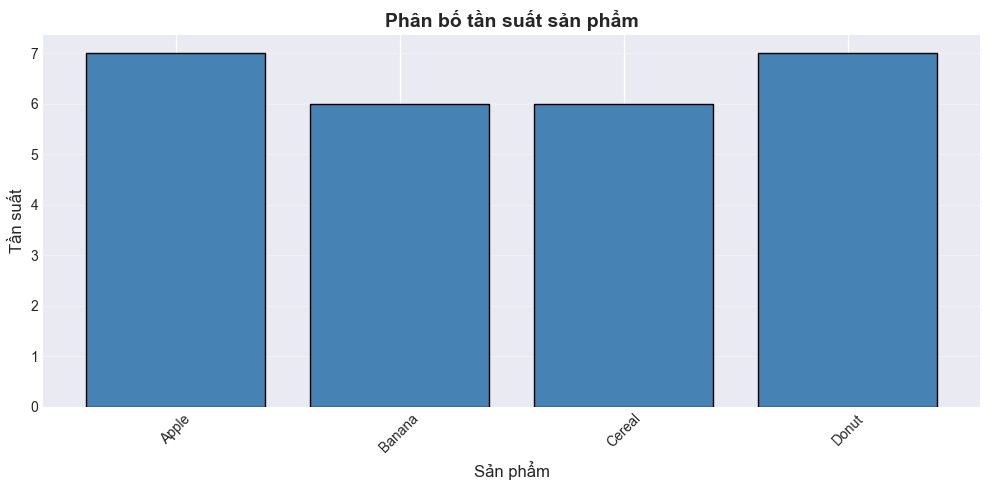

In [16]:
# Phân tích tần suất xuất hiện của từng item
all_items = []
for seq in sequences:
    all_items.extend(seq)

item_counts = Counter(all_items)
print("Phân bố tần suất item:")
for item, count in sorted(item_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"  {item}: {count} ({count/len(sequences)*100:.1f}%)")

# Trực quan hóa tần suất item
plt.figure(figsize=(10, 5))
items = list(item_counts.keys())
counts = list(item_counts.values())
plt.bar(items, counts, color='steelblue', edgecolor='black')
plt.xlabel('Sản phẩm', fontsize=12)
plt.ylabel('Tần suất', fontsize=12)
plt.title('Phân bố tần suất sản phẩm', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [17]:
class PrefixSpan:
    """
    Triển khai thuật toán PrefixSpan để khai phá mẫu tuần tự
    """
    def __init__(self, min_support=2):
        self.min_support = min_support
        self.patterns = []
        
    def is_subsequence(self, subseq, seq):
        """Kiểm tra xem subseq có phải là chuỗi con của seq không"""
        if len(subseq) == 0:
            return True
        if len(seq) == 0:
            return False
        
        subseq_idx = 0
        for item in seq:
            if item == subseq[subseq_idx]:
                subseq_idx += 1
                if subseq_idx == len(subseq):
                    return True
        return False
    
    def get_support(self, pattern, sequences):
        """Tính số lần xuất hiện (support count) của một mẫu"""
        count = 0
        for seq in sequences:
            if self.is_subsequence(pattern, seq):
                count += 1
        return count
    
    def get_frequent_items(self, sequences):
        """Tìm tất cả các chuỗi đơn (1-sequences) phổ biến"""
        item_counts = Counter()
        for seq in sequences:
            for item in set(seq):  # Sử dụng set để đếm mỗi item một lần trong mỗi chuỗi
                item_counts[item] += 1
        
        frequent_items = [(item,) for item, count in item_counts.items() 
                         if count >= self.min_support]
        return sorted(frequent_items)
    
    def project_database(self, pattern, sequences):
        """Tạo cơ sở dữ liệu chiếu cho một mẫu cho trước"""
        projected = []
        for seq in sequences:
            if self.is_subsequence(pattern, seq):
                # Tìm vị trí sau pattern
                pattern_idx = 0
                for i, item in enumerate(seq):
                    if item == pattern[pattern_idx]:
                        pattern_idx += 1
                        if pattern_idx == len(pattern):
                            # Thêm phần đuôi sau pattern
                            if i + 1 < len(seq):
                                projected.append(seq[i+1:])
                            break
        return projected
    
    def mine_patterns(self, prefix, sequences):
        """Khai phá mẫu đệ quy sử dụng phương pháp chiếu tiền tố"""
        # Tìm các item phổ biến trong cơ sở dữ liệu chiếu hiện tại
        item_counts = Counter()
        for seq in sequences:
            for item in set(seq):
                item_counts[item] += 1
        
        frequent_items = [(item,) for item, count in item_counts.items() 
                         if count >= self.min_support]
        
        for item in frequent_items:
            new_pattern = prefix + item
            support = self.get_support(new_pattern, self.original_sequences)
            
            # Lưu trữ mẫu cùng với support
            self.patterns.append((new_pattern, support))
            
            # Chiếu cơ sở dữ liệu và khai phá đệ quy
            projected = self.project_database(new_pattern, self.original_sequences)
            if projected:
                self.mine_patterns(new_pattern, projected)
    
    def fit(self, sequences):
        """Chạy thuật toán PrefixSpan"""
        self.original_sequences = sequences
        self.patterns = []
        
        # Lấy các chuỗi đơn phổ biến
        frequent_items = self.get_frequent_items(sequences)
        
        # Lưu trữ các chuỗi đơn
        for item in frequent_items:
            support = self.get_support(item, sequences)
            self.patterns.append((item, support))
        
        # Khai phá các mẫu dài hơn
        for item in frequent_items:
            projected = self.project_database(item, sequences)
            if projected:
                self.mine_patterns(item, projected)
        
        # Sắp xếp mẫu theo support (giảm dần) và độ dài
        self.patterns.sort(key=lambda x: (x[1], len(x[0])), reverse=True)
        
        return self.patterns
    
    def get_patterns(self, min_length=1):
        """Lấy các mẫu có độ dài tối thiểu"""
        return [(pattern, support) for pattern, support in self.patterns 
                if len(pattern) >= min_length]

print("Đã định nghĩa class PrefixSpan thành công!")


Đã định nghĩa class PrefixSpan thành công!


## 2. Apply PrefixSpan Algorithm


In [24]:
# Thử nghiệm với minimum support = 3 (30% giao dịch)
min_sup = 3
print(f"Khai phá mẫu tuần tự với Minimum Support = {min_sup} ({min_sup/len(sequences)*100:.0f}%)")
print("="*70)

prefixspan = PrefixSpan(min_support=min_sup)
patterns = prefixspan.fit(sequences)

print(f"\nTổng số mẫu tìm được: {len(patterns)}")
print("\nTất cả mẫu tuần tự phổ biến:")
print("-" * 70)

for i, (pattern, support) in enumerate(patterns, 1):
    pattern_str = " -> ".join(pattern)
    support_pct = support / len(sequences) * 100
    print(f"{i}. Mẫu: {pattern_str:30s} | Support: {support} ({support_pct:.1f}%)")


Khai phá mẫu tuần tự với Minimum Support = 3 (30%)

Tổng số mẫu tìm được: 11

Tất cả mẫu tuần tự phổ biến:
----------------------------------------------------------------------
1. Mẫu: Apple                          | Support: 7 (70.0%)
2. Mẫu: Donut                          | Support: 7 (70.0%)
3. Mẫu: Banana                         | Support: 6 (60.0%)
4. Mẫu: Cereal                         | Support: 6 (60.0%)
5. Mẫu: Apple -> Donut                 | Support: 5 (50.0%)
6. Mẫu: Apple -> Cereal                | Support: 4 (40.0%)
7. Mẫu: Apple -> Banana                | Support: 4 (40.0%)
8. Mẫu: Cereal -> Donut                | Support: 4 (40.0%)
9. Mẫu: Apple -> Cereal -> Donut       | Support: 3 (30.0%)
10. Mẫu: Banana -> Donut                | Support: 3 (30.0%)
11. Mẫu: Banana -> Cereal               | Support: 3 (30.0%)


In [25]:
# Nhóm các mẫu theo độ dài
print("\n" + "="*70)
print("Mẫu được nhóm theo độ dài:")
print("="*70)

patterns_by_length = {}
for pattern, support in patterns:
    length = len(pattern)
    if length not in patterns_by_length:
        patterns_by_length[length] = []
    patterns_by_length[length].append((pattern, support))

for length in sorted(patterns_by_length.keys()):
    print(f"\nChuỗi {length}-phần tử ({len(patterns_by_length[length])} mẫu):")
    print("-" * 70)
    for pattern, support in patterns_by_length[length]:
        pattern_str = " -> ".join(pattern)
        support_pct = support / len(sequences) * 100
        print(f"  {pattern_str:30s} | Support: {support} ({support_pct:.1f}%)")



Mẫu được nhóm theo độ dài:

Chuỗi 1-phần tử (4 mẫu):
----------------------------------------------------------------------
  Apple                          | Support: 7 (70.0%)
  Donut                          | Support: 7 (70.0%)
  Banana                         | Support: 6 (60.0%)
  Cereal                         | Support: 6 (60.0%)

Chuỗi 2-phần tử (6 mẫu):
----------------------------------------------------------------------
  Apple -> Donut                 | Support: 5 (50.0%)
  Apple -> Cereal                | Support: 4 (40.0%)
  Apple -> Banana                | Support: 4 (40.0%)
  Cereal -> Donut                | Support: 4 (40.0%)
  Banana -> Donut                | Support: 3 (30.0%)
  Banana -> Cereal               | Support: 3 (30.0%)

Chuỗi 3-phần tử (1 mẫu):
----------------------------------------------------------------------
  Apple -> Cereal -> Donut       | Support: 3 (30.0%)


## 3. Visualization & Analysis


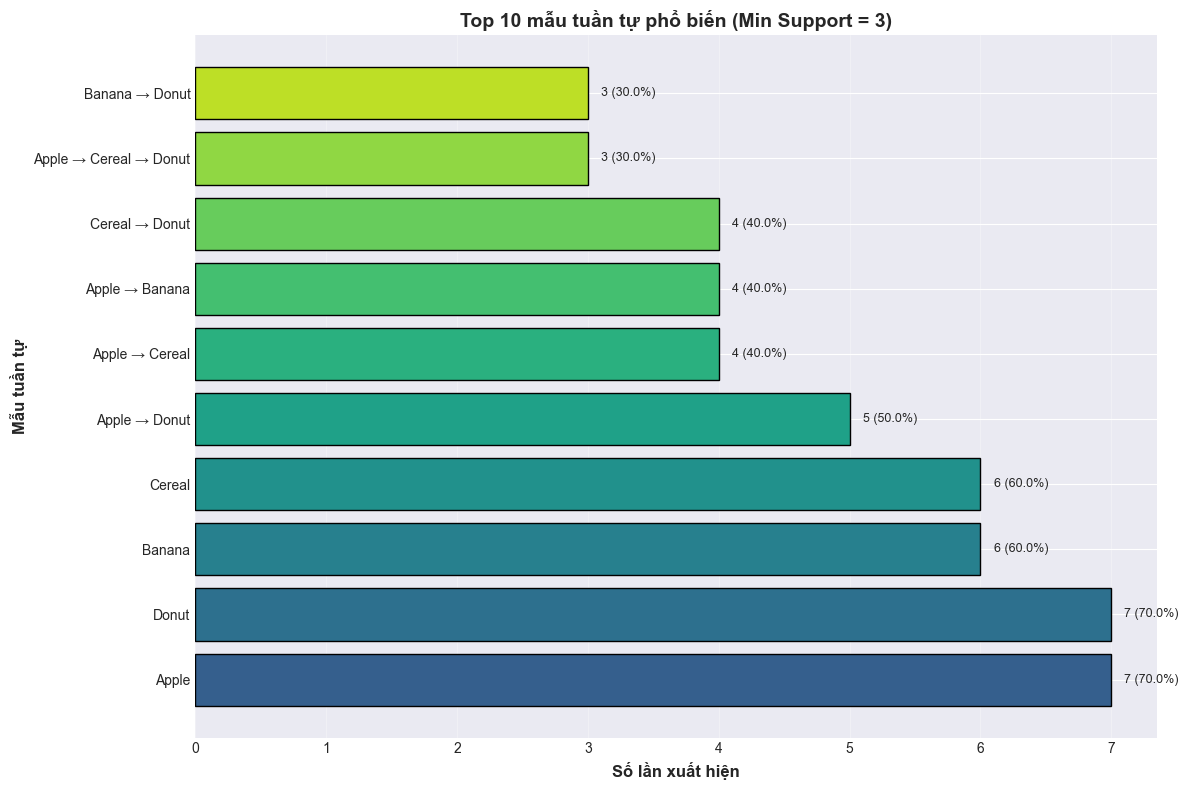

In [26]:
# Trực quan hóa các mẫu phổ biến nhất
top_n = 10
top_patterns = patterns[:top_n]

# Chuẩn bị dữ liệu để vẽ biểu đồ
pattern_labels = [" → ".join(p[0]) for p in top_patterns]
support_counts = [p[1] for p in top_patterns]

# Tạo biểu đồ cột ngang
plt.figure(figsize=(12, 8))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_patterns)))
bars = plt.barh(range(len(pattern_labels)), support_counts, color=colors, edgecolor='black')

plt.yticks(range(len(pattern_labels)), pattern_labels, fontsize=10)
plt.xlabel('Số lần xuất hiện', fontsize=12, fontweight='bold')
plt.ylabel('Mẫu tuần tự', fontsize=12, fontweight='bold')
plt.title(f'Top {top_n} mẫu tuần tự phổ biến (Min Support = {min_sup})', 
          fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# Thêm nhãn giá trị trên các cột
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height()/2, 
             f'{int(width)} ({width/len(sequences)*100:.1f}%)',
             va='center', fontsize=9)

plt.tight_layout()
plt.show()


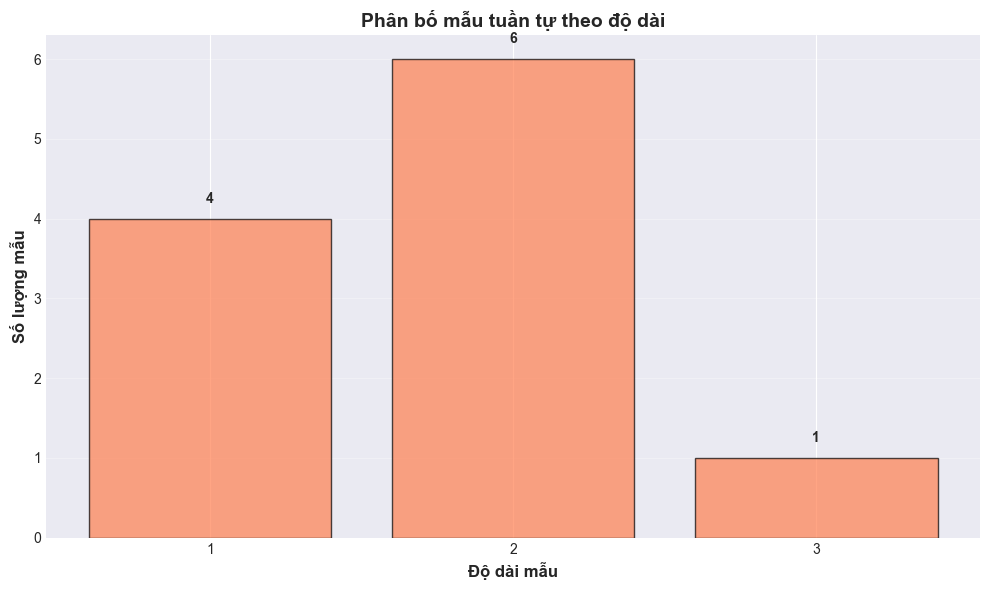


Thống kê độ dài mẫu:
  Mẫu ngắn nhất: 1 phần tử
  Mẫu dài nhất: 3 phần tử
  Độ dài trung bình: 1.73 phần tử


In [27]:
# Phân bố độ dài mẫu
plt.figure(figsize=(10, 6))
length_counts = [len(patterns_by_length.get(i, [])) for i in range(1, max(patterns_by_length.keys())+1)]
lengths = list(range(1, len(length_counts)+1))

plt.bar(lengths, length_counts, color='coral', edgecolor='black', alpha=0.7)
plt.xlabel('Độ dài mẫu', fontsize=12, fontweight='bold')
plt.ylabel('Số lượng mẫu', fontsize=12, fontweight='bold')
plt.title('Phân bố mẫu tuần tự theo độ dài', fontsize=14, fontweight='bold')
plt.xticks(lengths)
plt.grid(axis='y', alpha=0.3)

# Thêm nhãn giá trị
for i, count in enumerate(length_counts):
    plt.text(i+1, count + 0.2, str(count), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nThống kê độ dài mẫu:")
print(f"  Mẫu ngắn nhất: {min(patterns_by_length.keys())} phần tử")
print(f"  Mẫu dài nhất: {max(patterns_by_length.keys())} phần tử")
print(f"  Độ dài trung bình: {np.mean([len(p[0]) for p in patterns]):.2f} phần tử")



So sánh các ngưỡng Minimum Support khác nhau

Min Support = 2 (20%):
  Tổng số mẫu: 13
  Độ dài mẫu tối đa: 3

Min Support = 3 (30%):
  Tổng số mẫu: 11
  Độ dài mẫu tối đa: 3

Min Support = 4 (40%):
  Tổng số mẫu: 8
  Độ dài mẫu tối đa: 2

Min Support = 5 (50%):
  Tổng số mẫu: 5
  Độ dài mẫu tối đa: 2


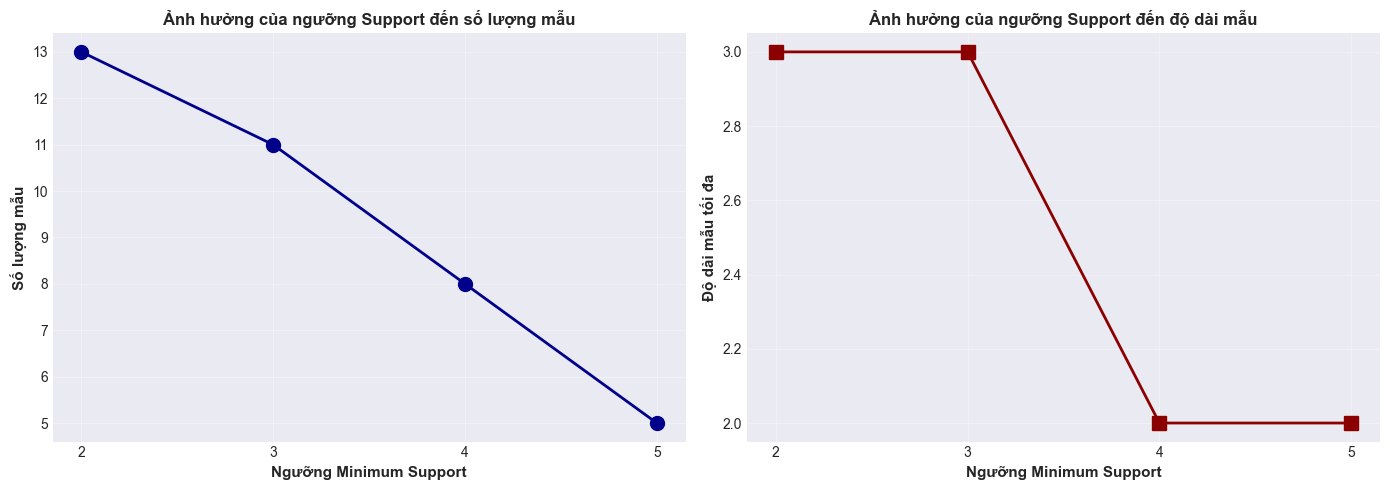

In [22]:
# So sánh các ngưỡng support khác nhau
print("\n" + "="*70)
print("So sánh các ngưỡng Minimum Support khác nhau")
print("="*70)

support_thresholds = [2, 3, 4, 5]
results = {}

for min_sup_test in support_thresholds:
    ps = PrefixSpan(min_support=min_sup_test)
    patterns_test = ps.fit(sequences)
    results[min_sup_test] = {
        'total_patterns': len(patterns_test),
        'max_length': max([len(p[0]) for p in patterns_test]) if patterns_test else 0,
        'patterns': patterns_test
    }
    print(f"\nMin Support = {min_sup_test} ({min_sup_test/len(sequences)*100:.0f}%):")
    print(f"  Tổng số mẫu: {results[min_sup_test]['total_patterns']}")
    print(f"  Độ dài mẫu tối đa: {results[min_sup_test]['max_length']}")

# Trực quan hóa so sánh
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ 1: Số lượng mẫu vs ngưỡng support
axes[0].plot(support_thresholds, [results[s]['total_patterns'] for s in support_thresholds], 
             marker='o', linewidth=2, markersize=10, color='darkblue')
axes[0].set_xlabel('Ngưỡng Minimum Support', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Số lượng mẫu', fontsize=11, fontweight='bold')
axes[0].set_title('Ảnh hưởng của ngưỡng Support đến số lượng mẫu', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(support_thresholds)

# Biểu đồ 2: Độ dài mẫu tối đa vs ngưỡng support
axes[1].plot(support_thresholds, [results[s]['max_length'] for s in support_thresholds], 
             marker='s', linewidth=2, markersize=10, color='darkred')
axes[1].set_xlabel('Ngưỡng Minimum Support', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Độ dài mẫu tối đa', fontsize=11, fontweight='bold')
axes[1].set_title('Ảnh hưởng của ngưỡng Support đến độ dài mẫu', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(support_thresholds)

plt.tight_layout()
plt.show()


## 4. Key Insights


In [23]:
# Phân tích các insight chính từ các mẫu được khám phá
print("="*70)
print("CÁC INSIGHT CHÍNH TỪ KHAI PHÁ MẪU TUẦN TỰ")
print("="*70)

# Lấy các mẫu có support >= 3
frequent_patterns = [(p, s) for p, s in patterns if s >= 3]

print(f"\n1. CÁC SẢN PHẨM PHỔ BIẾN NHẤT:")
print("-" * 70)
single_items = [(p, s) for p, s in frequent_patterns if len(p) == 1]
for pattern, support in sorted(single_items, key=lambda x: x[1], reverse=True)[:5]:
    print(f"   • {pattern[0]:15s} xuất hiện trong {support}/10 giao dịch ({support*10}%)")

print(f"\n2. CHUỖI 2 SẢN PHẨM PHỔ BIẾN NHẤT:")
print("-" * 70)
two_items = [(p, s) for p, s in frequent_patterns if len(p) == 2]
if two_items:
    for pattern, support in sorted(two_items, key=lambda x: x[1], reverse=True)[:5]:
        print(f"   • {' → '.join(pattern):30s} (Support: {support}, {support*10}%)")
else:
    print("   Không tìm thấy chuỗi 2 sản phẩm với ngưỡng support hiện tại")

print(f"\n3. CHUỖI DÀI NHẤT PHỔ BIẾN:")
print("-" * 70)
max_len = max([len(p) for p, s in frequent_patterns])
longest = [(p, s) for p, s in frequent_patterns if len(p) == max_len]
for pattern, support in sorted(longest, key=lambda x: x[1], reverse=True)[:3]:
    print(f"   • {' → '.join(pattern):40s} (Support: {support})")

print(f"\n4. THỐNG KÊ MẪU TUẦN TỰ:")
print("-" * 70)
print(f"   • Tổng số giao dịch phân tích: {len(sequences)}")
print(f"   • Số sản phẩm duy nhất: {len(set(all_items))}")
print(f"   • Mẫu phổ biến tìm được (min_sup={min_sup}): {len(frequent_patterns)}")
print(f"   • Độ dài chuỗi trung bình: {np.mean([len(seq) for seq in sequences]):.2f} sản phẩm")
print(f"   • Sản phẩm bắt đầu phổ biến nhất: {single_items[0][0][0]} ({single_items[0][1]} lần)")

# Tìm các sản phẩm thường xuất hiện cùng nhau theo trình tự
print(f"\n5. CHUYỂN ĐỔI SẢN PHẨM PHỔ BIẾN:")
print("-" * 70)
if two_items:
    transitions = {}
    for pattern, support in two_items:
        from_item, to_item = pattern
        if from_item not in transitions:
            transitions[from_item] = []
        transitions[from_item].append((to_item, support))
    
    for from_item in sorted(transitions.keys()):
        print(f"   Sau khi mua '{from_item}', khách hàng thường mua:")
        for to_item, sup in sorted(transitions[from_item], key=lambda x: x[1], reverse=True)[:3]:
            print(f"      → {to_item} (trong {sup} giao dịch)")


CÁC INSIGHT CHÍNH TỪ KHAI PHÁ MẪU TUẦN TỰ

1. CÁC SẢN PHẨM PHỔ BIẾN NHẤT:
----------------------------------------------------------------------
   • Apple           xuất hiện trong 7/10 giao dịch (70%)
   • Donut           xuất hiện trong 7/10 giao dịch (70%)
   • Banana          xuất hiện trong 6/10 giao dịch (60%)
   • Cereal          xuất hiện trong 6/10 giao dịch (60%)

2. CHUỖI 2 SẢN PHẨM PHỔ BIẾN NHẤT:
----------------------------------------------------------------------
   • Apple → Donut                  (Support: 5, 50%)
   • Apple → Cereal                 (Support: 4, 40%)
   • Apple → Banana                 (Support: 4, 40%)
   • Cereal → Donut                 (Support: 4, 40%)
   • Banana → Donut                 (Support: 3, 30%)

3. CHUỖI DÀI NHẤT PHỔ BIẾN:
----------------------------------------------------------------------
   • Apple → Cereal → Donut                   (Support: 3)

4. THỐNG KÊ MẪU TUẦN TỰ:
-------------------------------------------------------------